# House Prices EDA and Hypothesis Testing

## Project Overview
This notebook performs exploratory data analysis on house sales data from King County, Washington.

### Analysis includes:
1. **Data Loading & Initial Exploration** - Understanding dataset structure
2. **Data Quality Check** - Missing values, duplicates
3. **Price Distribution Analysis** - Skewness, outliers detection
4. **Geospatial Analysis** - Mapping house locations by zip code
5. **Correlation Analysis** - Identifying factors affecting price
6. **Hypothesis Testing** - Statistical regression analysis
7. **Key Findings & Insights** - Discoveries and actionable insights
8. **Conclusion & Next Steps** - Modeling, Validation & Metrics

---
## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

---
# Research Plan

## Objective
Analyze the King County house sales dataset to understand factors influencing house prices and build a foundation for predictive modeling.

## Research Steps

| Step | Description | Expected Outcome |
|------|-------------|------------------|
| 1. Data Loading & Exploration | Load dataset, examine structure | Understanding of dataset dimensions and features |
| 2. Data Quality Assessment | Check missing values, duplicates, data types | Clean dataset ready for analysis |
| 3. Exploratory Data Analysis | Statistical summaries, distributions | Insights into variable distributions |
| 4. Outlier Detection & Treatment | Identify and handle extreme values | Dataset without distorting outliers |
| 5. Feature Engineering | Create new features, transformations | Enhanced feature set for modeling |
| 6. Hypothesis Testing | Statistical tests for relationships | Validated insights about price drivers |
| 7. Correlation Analysis | Examine relationships between variables | Understanding of feature interactions |
| 8. Visualization | Create informative plots | Visual insights for stakeholders |

## Key Questions to Answer
1. What features have the strongest influence on house prices?
2. Does the living area significantly affect price?
3. Do houses with waterfront views command premium prices?
4. How does the year built affect house prices?
5. What is the geographic distribution of house prices?

---

# Hypotheses

Based on domain knowledge about real estate, I formulate the following hypotheses:

## Hypothesis 1: Living Area vs Price
**H₀ (Null):** There is no significant correlation between living area (sqft_living) and house price.
**H₁ (Alternative):** There is a significant positive correlation between living area and house price.
**Rationale:** Larger houses typically command higher prices due to more space.

## Hypothesis 2: Waterfront Property vs Price
**H₀ (Null):** There is no significant difference in price between waterfront and non-waterfront properties.
**H₁ (Alternative):** Waterfront properties have significantly higher prices than non-waterfront properties.
**Rationale:** Waterfront locations are rare and desirable, potentially commanding premium prices.

## Hypothesis 3: Year Built vs Price
**H₀ (Null):** There is no significant correlation between year built and house price.
**H₁ (Alternative):** There is a significant correlation between year built and house price.
**Rationale:** Newer houses may have modern amenities and require less maintenance.

## Hypothesis 4: Grade (Quality) vs Price
**H₀ (Null):** There is no significant correlation between building grade and house price.
**H₁ (Alternative):** Higher building grades are associated with significantly higher prices.
**Rationale:** Better construction quality and materials should increase value.

---

## 2. Load Data
Loading the house sales dataset from CSV file and displaying first 5 rows.

In [2]:
df = pd.read_csv("house_sales.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


---
# Data Cleaning & Feature Engineering

## 3.1 Data Quality Summary (Before Cleaning)
Let's examine the data quality before any transformations.

In [3]:
# Data quality summary before cleaning
print("=" * 60)
print("DATA QUALITY REPORT - BEFORE CLEANING")
print("=" * 60)

print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nData Types:")
print(df.dtypes)

# Check for potential issues
print("\n" + "=" * 60)
print("POTENTIAL DATA ISSUES")
print("=" * 60)
print(f"\nBedrooms = 0: {(df['bedrooms'] == 0).sum()} houses")
print(f"Bathrooms = 0: {(df['bathrooms'] == 0).sum()} houses")
print(f"Price = 0 or negative: {(df['price'] <= 0).sum()} houses")
print(f"Sqft_living = 0: {(df['sqft_living'] == 0).sum()} houses")

DATA QUALITY REPORT - BEFORE CLEANING

Dataset Shape: 21613 rows, 21 columns

Missing Values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Duplicate Rows: 0

Data Types:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long        

## 3.2 Data Cleaning Steps

In [4]:
# Create a copy for cleaning
df_clean = df.copy()

# Step 1: Remove houses with 0 bedrooms (likely data errors or commercial properties)
bedrooms_zero = (df_clean['bedrooms'] == 0).sum()
df_clean = df_clean[df_clean['bedrooms'] > 0]
print(f"Removed {bedrooms_zero} houses with 0 bedrooms")

# Step 2: Remove houses with 0 bathrooms
bathrooms_zero = (df_clean['bathrooms'] == 0).sum()
df_clean = df_clean[df_clean['bathrooms'] > 0]
print(f"Removed {bathrooms_zero} houses with 0 bathrooms")

# Step 3: Remove extreme bedroom outliers (houses with >10 bedrooms are likely errors)
extreme_bedrooms = (df_clean['bedrooms'] > 10).sum()
df_clean = df_clean[df_clean['bedrooms'] <= 10]
print(f"Removed {extreme_bedrooms} houses with >10 bedrooms")

# Step 4: Remove houses with price < $10,000 (likely errors or special sales)
low_price = (df_clean['price'] < 10000).sum()
df_clean = df_clean[df_clean['price'] >= 10000]
print(f"Removed {low_price} houses with price < $10,000")

print(f"\nDataset after cleaning: {df_clean.shape[0]} rows (removed {df.shape[0] - df_clean.shape[0]} rows total)")

Removed 13 houses with 0 bedrooms
Removed 3 houses with 0 bathrooms
Removed 2 houses with >10 bedrooms
Removed 0 houses with price < $10,000

Dataset after cleaning: 21595 rows (removed 18 rows total)


## 3.3 Feature Engineering

Feature engineering is crucial for improving model performance. I create new features that capture domain knowledge about real estate valuation.

### Why Feature Engineering?
- Raw features may not capture complex relationships
- Domain-specific features improve model interpretability
- Derived features can reveal hidden patterns
- Better features often matter more than complex algorithms

In [5]:
# Initialize current year for age calculations
current_year = 2015  # Dataset is from 2014-2015

### Step 1: Price per Square Foot

**What:** Divide price by living area to get cost per sqft.

**Why this matters:**
- Normalizes price comparison across different-sized homes
- Standard metric used by real estate professionals
- Reveals true value density (expensive small home vs cheap large home)
- Helps identify overpriced or underpriced properties

In [6]:
# Step 1: Price per square foot
df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft_living']

print("Price per Sqft Statistics:")
print(f"  Mean: ${df_clean['price_per_sqft'].mean():.2f}/sqft")
print(f"  Median: ${df_clean['price_per_sqft'].median():.2f}/sqft")
print(f"  Range: ${df_clean['price_per_sqft'].min():.2f} - ${df_clean['price_per_sqft'].max():.2f}/sqft")

Price per Sqft Statistics:
  Mean: $264.11/sqft
  Median: $244.64/sqft
  Range: $87.59 - $810.14/sqft


### Step 2: House Age

**What:** Calculate years since the house was built.

**Why this matters:**
- Age directly impacts depreciation and maintenance needs
- Newer homes have modern building codes, better insulation, updated electrical/plumbing
- Some buyers prefer new construction, others value older "character" homes
- Age correlates with renovation likelihood and repair costs

In [7]:
# Step 2: House age
df_clean['house_age'] = current_year - df_clean['yr_built']

print("House Age Statistics:")
print(f"  Newest: {df_clean['house_age'].min()} years old (built {df_clean['yr_built'].max()})")
print(f"  Oldest: {df_clean['house_age'].max()} years old (built {df_clean['yr_built'].min()})")
print(f"  Average: {df_clean['house_age'].mean():.1f} years old")

House Age Statistics:
  Newest: 0 years old (built 2015)
  Oldest: 115 years old (built 1900)
  Average: 44.0 years old


### Step 3: Renovation Status

**What:** Binary indicator whether house was ever renovated.

**Why this matters:**
- Renovations typically add 10-30% to home value
- Updated kitchens/bathrooms are top value drivers
- Renovated homes often sell faster
- Indicates proactive maintenance by previous owners

In [8]:
# Step 3: Renovation status (binary)
df_clean['is_renovated'] = (df_clean['yr_renovated'] > 0).astype(int)

renovated_count = df_clean['is_renovated'].sum()
total_count = len(df_clean)
print("Renovation Statistics:")
print(f"  Renovated: {renovated_count} houses ({renovated_count/total_count*100:.1f}%)")
print(f"  Not renovated: {total_count - renovated_count} houses ({(total_count-renovated_count)/total_count*100:.1f}%)")
print(f"\nPrice Comparison:")
print(f"  Avg price (renovated): ${df_clean[df_clean['is_renovated']==1]['price'].mean():,.0f}")
print(f"  Avg price (not renovated): ${df_clean[df_clean['is_renovated']==0]['price'].mean():,.0f}")
print(f"  Premium: {(df_clean[df_clean['is_renovated']==1]['price'].mean() / df_clean[df_clean['is_renovated']==0]['price'].mean() - 1)*100:.1f}%")

Renovation Statistics:
  Renovated: 913 houses (4.2%)
  Not renovated: 20682 houses (95.8%)

Price Comparison:
  Avg price (renovated): $760,642
  Avg price (not renovated): $530,468
  Premium: 43.4%


### Step 4: Years Since Renovation

**What:** For renovated houses - years since renovation. For non-renovated - use house age.

**Why this matters:**
- Recent renovations (< 10 years) are more valuable than older ones
- Captures "effective age" of the property
- Kitchen/bathroom updates typically last 15-20 years before needing refresh
- Helps predict future maintenance needs

In [9]:
# Step 4: Years since renovation (or house age if never renovated)
df_clean['years_since_renovation'] = df_clean.apply(
    lambda x: current_year - x['yr_renovated'] if x['yr_renovated'] > 0 else x['house_age'], 
    axis=1
)

print("Years Since Last Major Work:")
print(f"  Mean: {df_clean['years_since_renovation'].mean():.1f} years")
print(f"  Median: {df_clean['years_since_renovation'].median():.1f} years")
print(f"  Range: {df_clean['years_since_renovation'].min()} - {df_clean['years_since_renovation'].max()} years")

Years Since Last Major Work:
  Mean: 41.6 years
  Median: 38.0 years
  Range: 0 - 115 years


### Step 5: Total Rooms

**What:** Sum of bedrooms and bathrooms.

**Why this matters:**
- Single metric for overall house capacity
- Common search filter for home buyers ("I need 4+ rooms")
- Simplifies comparisons between properties
- Correlates with family size requirements

In [10]:
# Step 5: Total rooms (bedrooms + bathrooms)
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']

print("Total Rooms Statistics:")
print(f"  Range: {df_clean['total_rooms'].min():.1f} - {df_clean['total_rooms'].max():.1f} rooms")
print(f"  Average: {df_clean['total_rooms'].mean():.1f} rooms")
print(f"  Most common: {df_clean['total_rooms'].mode().values[0]:.1f} rooms")

Total Rooms Statistics:
  Range: 1.5 - 16.5 rooms
  Average: 5.5 rooms
  Most common: 6.5 rooms


### Step 6: Living to Lot Ratio

**What:** Ratio of living area to total lot size.

**Why this matters:**
- High ratio = larger house on smaller lot (urban, less yard)
- Low ratio = smaller house on larger lot (suburban, more outdoor space)
- Different buyers have different preferences (families vs. professionals)
- Affects property taxes and maintenance requirements

In [11]:
# Step 6: Living to lot ratio
df_clean['living_lot_ratio'] = df_clean['sqft_living'] / df_clean['sqft_lot']

print("Living/Lot Ratio Statistics:")
print(f"  Mean: {df_clean['living_lot_ratio'].mean():.3f}")
print(f"  Median: {df_clean['living_lot_ratio'].median():.3f}")
print("  Interpretation: Higher = more building, Lower = more yard")

Living/Lot Ratio Statistics:
  Mean: 0.324
  Median: 0.248
  Interpretation: Higher = more building, Lower = more yard


### Step 7: Has Basement

**What:** Binary indicator for basement presence.

**Why this matters:**
- Basements add significant usable/storage space
- Can be finished for additional living area
- Adds $10,000-$50,000+ in value depending on size
- Valuable for storage, home office, entertainment

In [12]:
# Step 7: Has basement (binary)
df_clean['has_basement'] = (df_clean['sqft_basement'] > 0).astype(int)

basement_count = df_clean['has_basement'].sum()
print("Basement Statistics:")
print(f"  With basement: {basement_count} houses ({basement_count/len(df_clean)*100:.1f}%)")
print(f"  Without basement: {len(df_clean) - basement_count} houses")
print(f"\nPrice Comparison:")
print(f"  Avg price (with): ${df_clean[df_clean['has_basement']==1]['price'].mean():,.0f}")
print(f"  Avg price (without): ${df_clean[df_clean['has_basement']==0]['price'].mean():,.0f}")

Basement Statistics:
  With basement: 8485 houses (39.3%)
  Without basement: 13110 houses

Price Comparison:
  Avg price (with): $622,384
  Avg price (without): $487,008


### Step 8: Price Category

**What:** Bin prices into market segments (Budget, Moderate, Mid-High, High, Luxury).

**Why this matters:**
- Enables market segment analysis
- Different segments have different price drivers
- Useful for stratified sampling and modeling
- Helps target marketing strategies

In [13]:
# Step 8: Price category (market segmentation)
df_clean['price_category'] = pd.cut(
    df_clean['price'], 
    bins=[0, 250000, 500000, 750000, 1000000, float('inf')],
    labels=['Budget (<$250K)', 'Moderate ($250K-$500K)', 'Mid-High ($500K-$750K)', 
            'High ($750K-$1M)', 'Luxury (>$1M)']
)

print("Market Segment Distribution:")
print(df_clean['price_category'].value_counts().sort_index())
print(f"\nPercentage:")
for cat in df_clean['price_category'].cat.categories:
    pct = (df_clean['price_category'] == cat).sum() / len(df_clean) * 100
    print(f"  {cat}: {pct:.1f}%")

Market Segment Distribution:
price_category
Budget (<$250K)            2427
Moderate ($250K-$500K)    10119
Mid-High ($500K-$750K)     5470
High ($750K-$1M)           2116
Luxury (>$1M)              1463
Name: count, dtype: int64

Percentage:
  Budget (<$250K): 11.2%
  Moderate ($250K-$500K): 46.9%
  Mid-High ($500K-$750K): 25.3%
  High ($750K-$1M): 9.8%
  Luxury (>$1M): 6.8%


### Feature Engineering Summary

We created **8 new features** that capture important real estate domain knowledge:

| # | Feature | Type | Business Value |
|---|---------|------|----------------|
| 1 | `price_per_sqft` | Continuous | Normalized price comparison |
| 2 | `house_age` | Continuous | Depreciation & maintenance indicator |
| 3 | `is_renovated` | Binary | Value-add from updates |
| 4 | `years_since_renovation` | Continuous | Recency of improvements |
| 5 | `total_rooms` | Continuous | Overall capacity metric |
| 6 | `living_lot_ratio` | Continuous | Land utilization pattern |
| 7 | `has_basement` | Binary | Extra space indicator |
| 8 | `price_category` | Categorical | Market segmentation |

**Total features after engineering: 29 (21 original + 8 new)**

## 3.4 Data Quality Summary (After Cleaning)

In [14]:
# Data quality summary after cleaning
print("=" * 60)
print("DATA QUALITY REPORT - AFTER CLEANING")
print("=" * 60)

print(f"\nDataset Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"\nNew columns added: {df_clean.shape[1] - df.shape[1]}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]} ({(df.shape[0] - df_clean.shape[0])/df.shape[0]*100:.2f}%)")

print("\nNew Features Summary:")
print(df_clean[['price_per_sqft', 'house_age', 'is_renovated', 'total_rooms', 
                'living_lot_ratio', 'has_basement']].describe())

DATA QUALITY REPORT - AFTER CLEANING

Dataset Shape: 21595 rows, 29 columns

New columns added: 8
Rows removed: 18 (0.08%)

New Features Summary:
       price_per_sqft     house_age  is_renovated   total_rooms  \
count    21595.000000  21595.000000  21595.000000  21595.000000   
mean       264.114433     43.996759      0.042278      5.487277   
std        109.960081     29.373926      0.201228      1.462716   
min         87.588235      0.000000      0.000000      1.500000   
25%        182.291667     18.000000      0.000000      4.500000   
50%        244.644550     40.000000      0.000000      5.500000   
75%        318.283961     64.000000      0.000000      6.500000   
max        810.138889    115.000000      1.000000     16.500000   

       living_lot_ratio  has_basement  
count      21595.000000  21595.000000  
mean           0.323745      0.392915  
std            0.268465      0.488410  
min            0.000610      0.000000  
25%            0.156634      0.000000  
50%       

## 3.5 Before vs After Comparison Table

In [15]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Missing Values', 'Duplicates', 
               'Min Price', 'Max Price', 'Mean Price', 'Min Bedrooms', 'Max Bedrooms'],
    'Before Cleaning': [
        df.shape[0], df.shape[1], df.isnull().sum().sum(), df.duplicated().sum(),
        f"${df['price'].min():,.0f}", f"${df['price'].max():,.0f}", 
        f"${df['price'].mean():,.0f}", df['bedrooms'].min(), df['bedrooms'].max()
    ],
    'After Cleaning': [
        df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum(),
        f"${df_clean['price'].min():,.0f}", f"${df_clean['price'].max():,.0f}",
        f"${df_clean['price'].mean():,.0f}", df_clean['bedrooms'].min(), df_clean['bedrooms'].max()
    ]
})
print(comparison.to_string(index=False))

        Metric Before Cleaning After Cleaning
    Total Rows           21613          21595
 Total Columns              21             29
Missing Values               0              0
    Duplicates               0              0
     Min Price         $75,000        $78,000
     Max Price      $7,700,000     $7,700,000
    Mean Price        $540,088       $540,199
  Min Bedrooms               0              1
  Max Bedrooms              33             10


---
# Comprehensive Visualizations

## 4.1 Distribution Analysis - Histograms

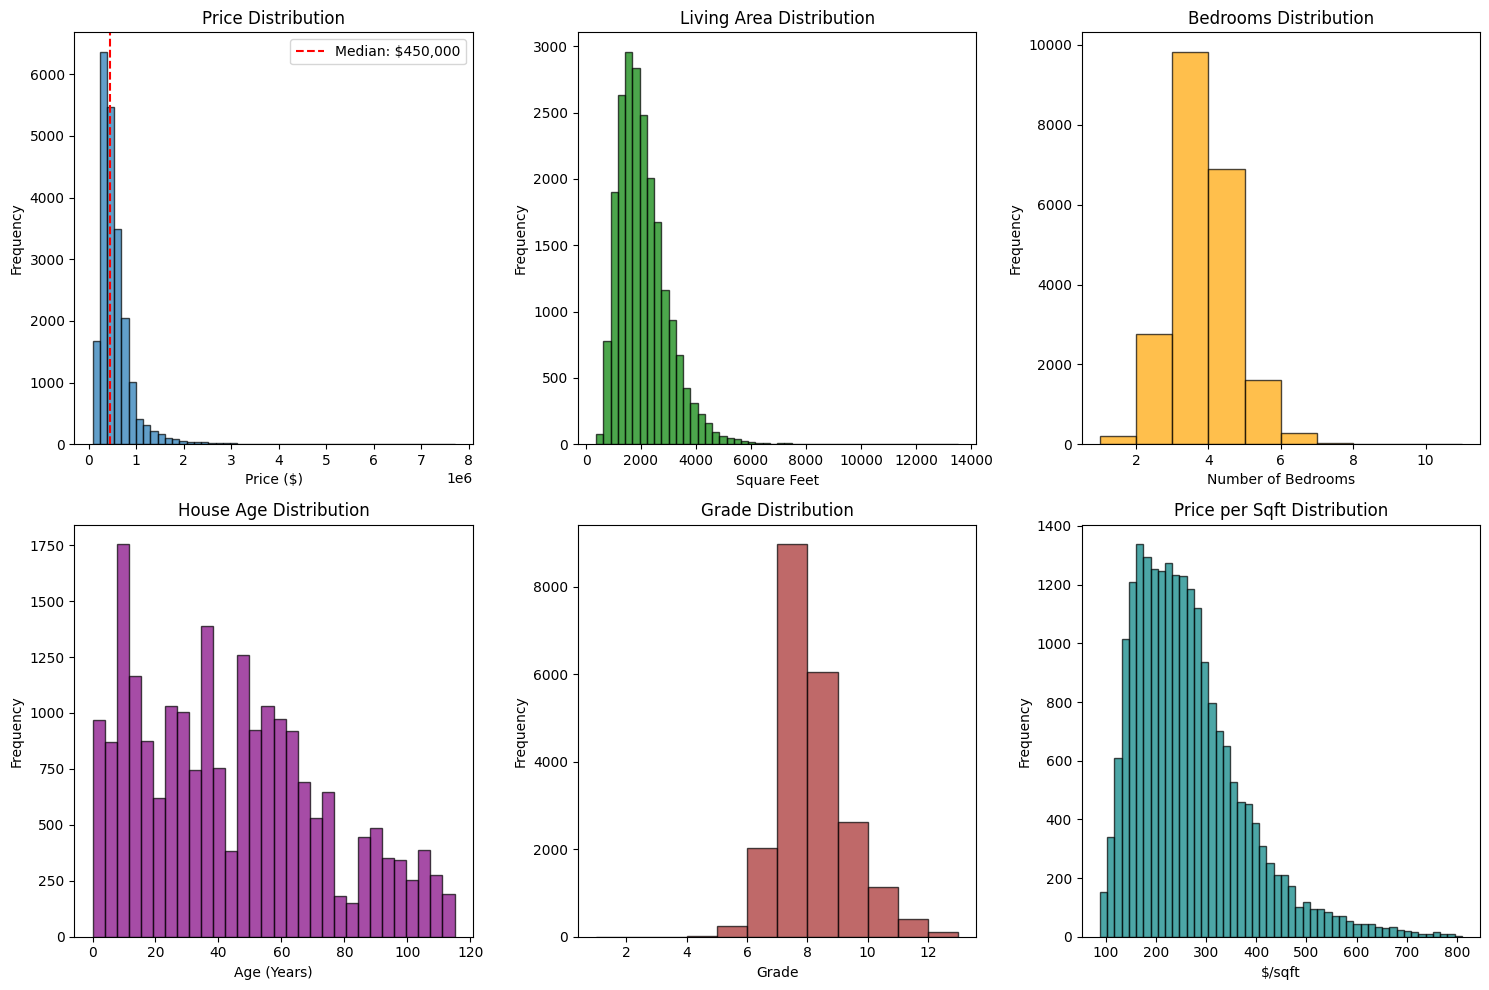

In [16]:
# Histograms for key numeric variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Price distribution
axes[0, 0].hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_clean['price'].median(), color='red', linestyle='--', label=f'Median: ${df_clean["price"].median():,.0f}')
axes[0, 0].legend()

# Living area distribution
axes[0, 1].hist(df_clean['sqft_living'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Living Area Distribution')
axes[0, 1].set_xlabel('Square Feet')
axes[0, 1].set_ylabel('Frequency')

# Bedrooms distribution
axes[0, 2].hist(df_clean['bedrooms'], bins=range(1, 12), edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_title('Bedrooms Distribution')
axes[0, 2].set_xlabel('Number of Bedrooms')
axes[0, 2].set_ylabel('Frequency')

# House age distribution
axes[1, 0].hist(df_clean['house_age'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_title('House Age Distribution')
axes[1, 0].set_xlabel('Age (Years)')
axes[1, 0].set_ylabel('Frequency')

# Grade distribution
axes[1, 1].hist(df_clean['grade'], bins=range(1, 14), edgecolor='black', alpha=0.7, color='brown')
axes[1, 1].set_title('Grade Distribution')
axes[1, 1].set_xlabel('Grade')
axes[1, 1].set_ylabel('Frequency')

# Price per sqft distribution
axes[1, 2].hist(df_clean['price_per_sqft'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1, 2].set_title('Price per Sqft Distribution')
axes[1, 2].set_xlabel('$/sqft')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4.2 Box Plots - Identifying Outliers and Distributions

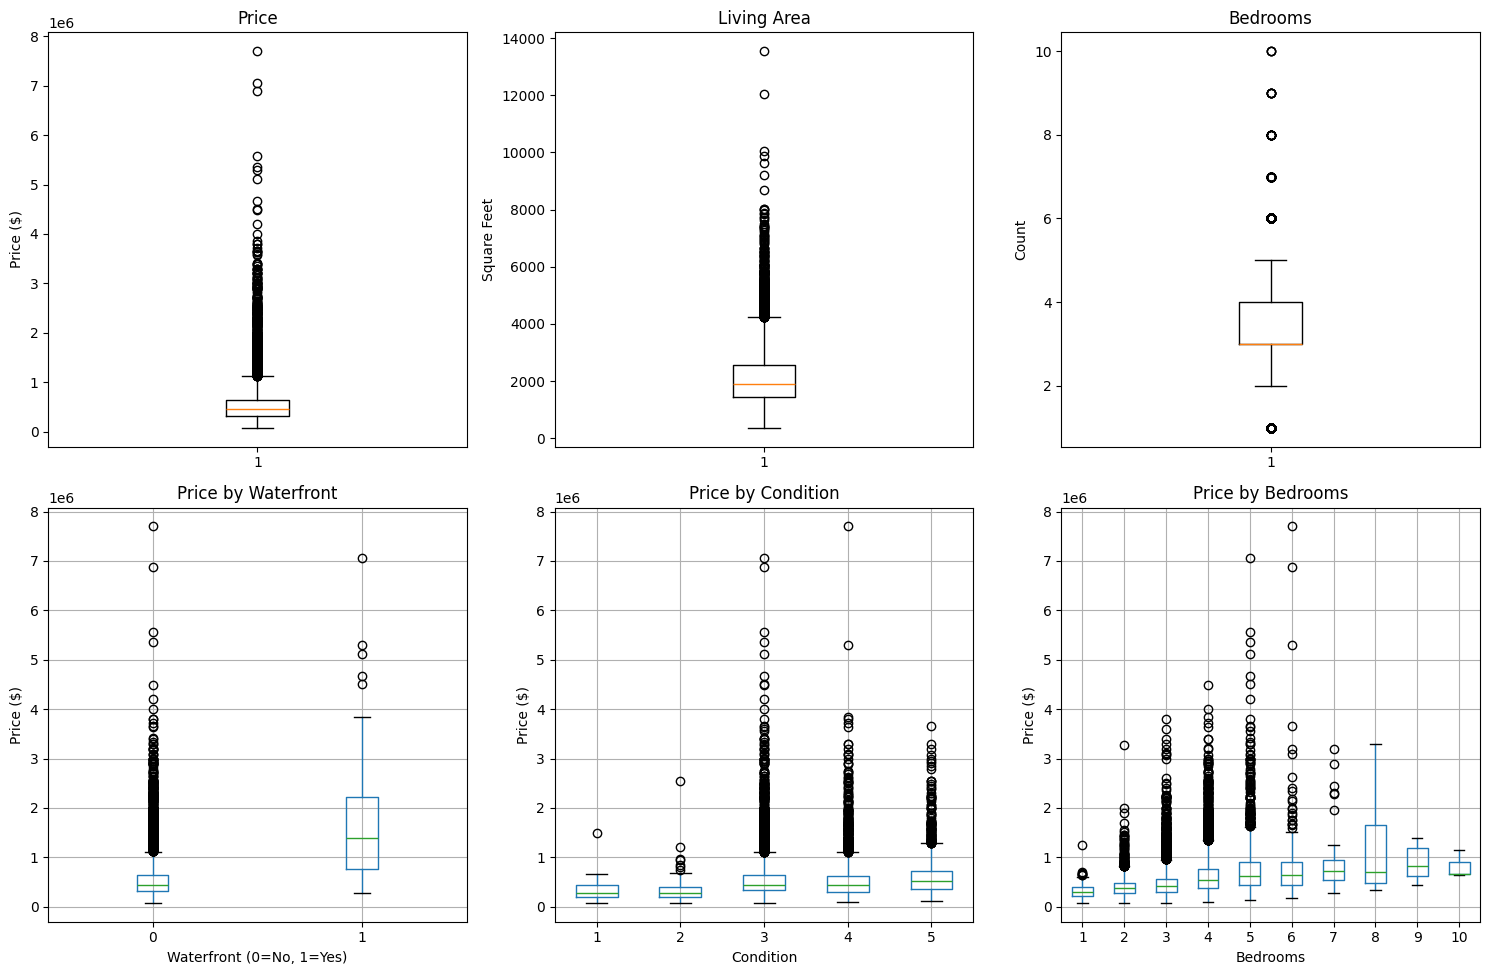

In [17]:
# Box plots for key variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Price boxplot
axes[0, 0].boxplot(df_clean['price'])
axes[0, 0].set_title('Price')
axes[0, 0].set_ylabel('Price ($)')

# Living area boxplot
axes[0, 1].boxplot(df_clean['sqft_living'])
axes[0, 1].set_title('Living Area')
axes[0, 1].set_ylabel('Square Feet')

# Bedrooms boxplot
axes[0, 2].boxplot(df_clean['bedrooms'])
axes[0, 2].set_title('Bedrooms')
axes[0, 2].set_ylabel('Count')

# Price by waterfront
df_clean.boxplot(column='price', by='waterfront', ax=axes[1, 0])
axes[1, 0].set_title('Price by Waterfront')
axes[1, 0].set_xlabel('Waterfront (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Price ($)')
plt.suptitle('')

# Price by condition
df_clean.boxplot(column='price', by='condition', ax=axes[1, 1])
axes[1, 1].set_title('Price by Condition')
axes[1, 1].set_xlabel('Condition')
axes[1, 1].set_ylabel('Price ($)')
plt.suptitle('')

# Price by bedrooms
df_clean.boxplot(column='price', by='bedrooms', ax=axes[1, 2])
axes[1, 2].set_title('Price by Bedrooms')
axes[1, 2].set_xlabel('Bedrooms')
axes[1, 2].set_ylabel('Price ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4.3 Scatter Plots - Relationships Between Variables

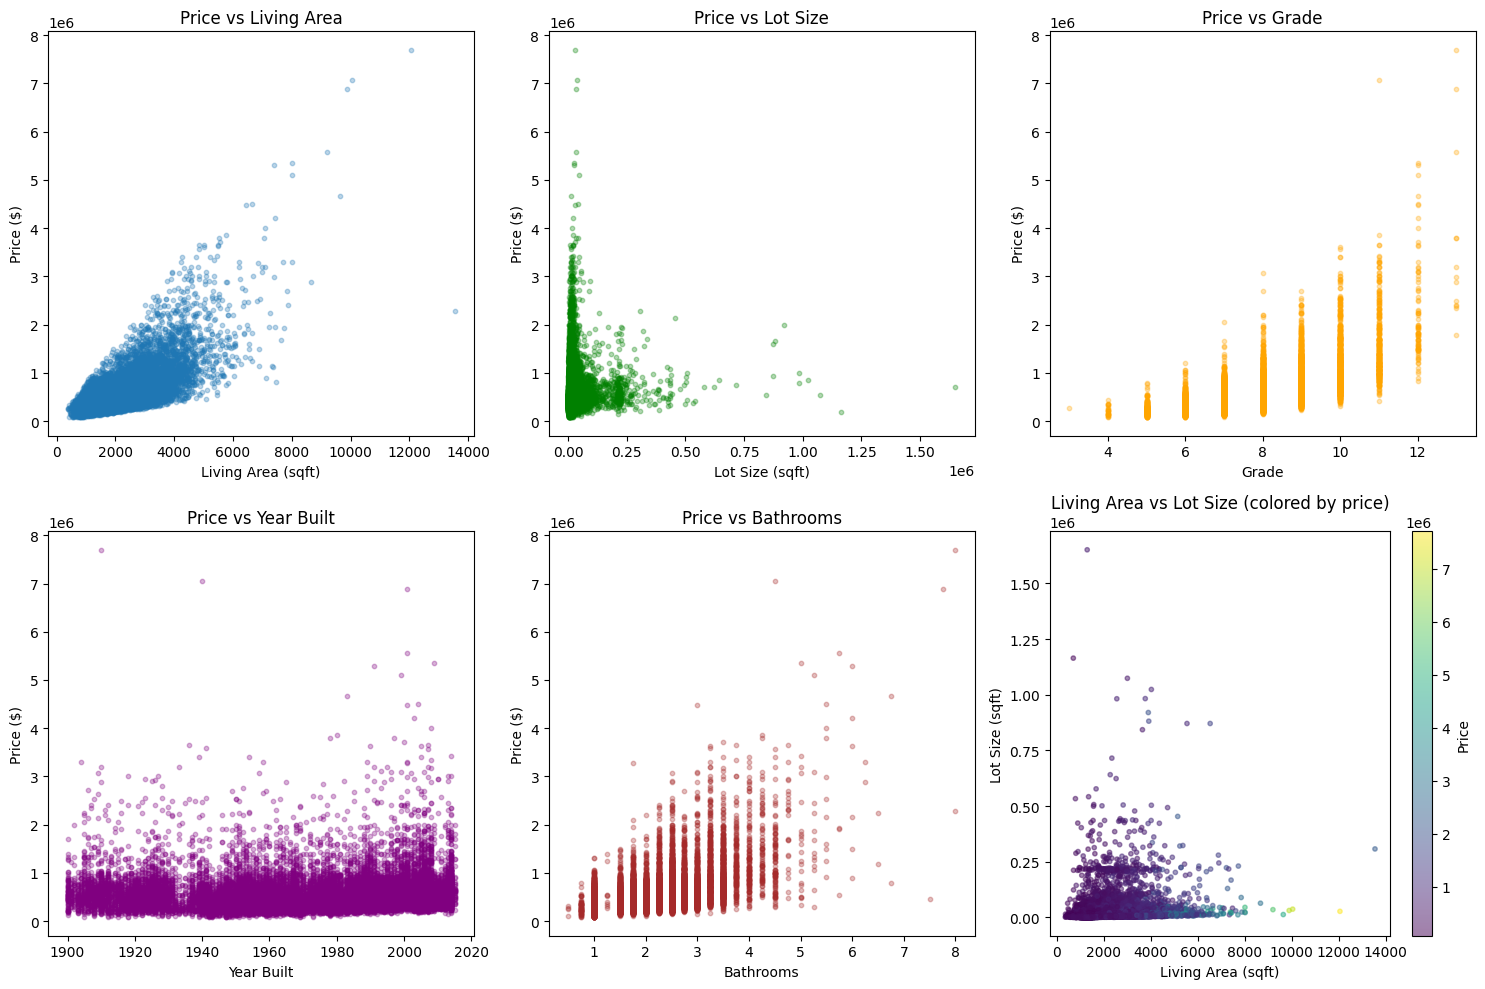

In [18]:
# Scatter plots showing relationships with price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Price vs Living Area
axes[0, 0].scatter(df_clean['sqft_living'], df_clean['price'], alpha=0.3, s=10)
axes[0, 0].set_title('Price vs Living Area')
axes[0, 0].set_xlabel('Living Area (sqft)')
axes[0, 0].set_ylabel('Price ($)')

# Price vs Lot Size
axes[0, 1].scatter(df_clean['sqft_lot'], df_clean['price'], alpha=0.3, s=10, color='green')
axes[0, 1].set_title('Price vs Lot Size')
axes[0, 1].set_xlabel('Lot Size (sqft)')
axes[0, 1].set_ylabel('Price ($)')

# Price vs Grade
axes[0, 2].scatter(df_clean['grade'], df_clean['price'], alpha=0.3, s=10, color='orange')
axes[0, 2].set_title('Price vs Grade')
axes[0, 2].set_xlabel('Grade')
axes[0, 2].set_ylabel('Price ($)')

# Price vs Year Built
axes[1, 0].scatter(df_clean['yr_built'], df_clean['price'], alpha=0.3, s=10, color='purple')
axes[1, 0].set_title('Price vs Year Built')
axes[1, 0].set_xlabel('Year Built')
axes[1, 0].set_ylabel('Price ($)')

# Price vs Bathrooms
axes[1, 1].scatter(df_clean['bathrooms'], df_clean['price'], alpha=0.3, s=10, color='brown')
axes[1, 1].set_title('Price vs Bathrooms')
axes[1, 1].set_xlabel('Bathrooms')
axes[1, 1].set_ylabel('Price ($)')

# Living Area vs Lot Size (colored by price)
scatter = axes[1, 2].scatter(df_clean['sqft_living'], df_clean['sqft_lot'], 
                              c=df_clean['price'], cmap='viridis', alpha=0.5, s=10)
axes[1, 2].set_title('Living Area vs Lot Size (colored by price)')
axes[1, 2].set_xlabel('Living Area (sqft)')
axes[1, 2].set_ylabel('Lot Size (sqft)')
plt.colorbar(scatter, ax=axes[1, 2], label='Price')

plt.tight_layout()
plt.show()

## 4.4 Correlation Heatmap

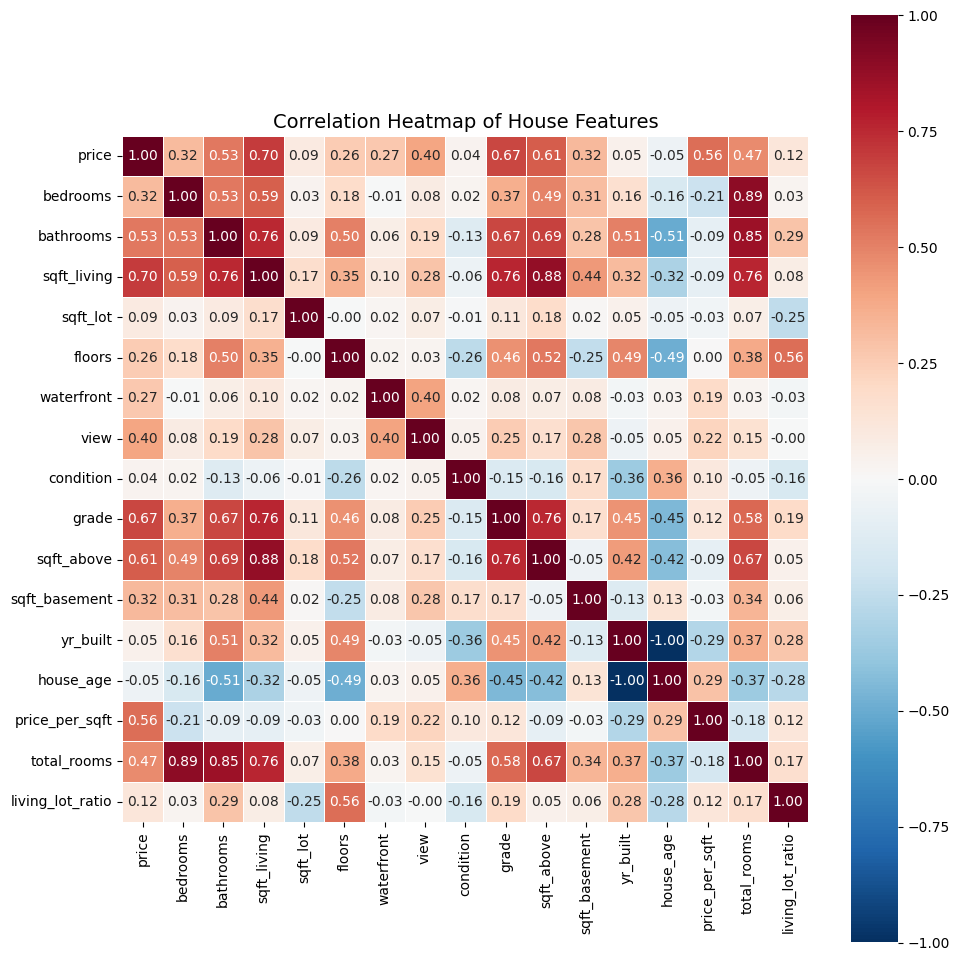


Top 10 Correlations with Price:
price             1.000000
sqft_living       0.701940
grade             0.667939
sqft_above        0.605405
price_per_sqft    0.555707
bathrooms         0.525934
total_rooms       0.471817
view              0.397323
sqft_basement     0.323777
bedrooms          0.316510
Name: price, dtype: float64


In [19]:
# Comprehensive correlation heatmap
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                'floors', 'waterfront', 'view', 'condition', 'grade', 
                'sqft_above', 'sqft_basement', 'yr_built', 'house_age',
                'price_per_sqft', 'total_rooms', 'living_lot_ratio']

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of House Features', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with price
print("\nTop 10 Correlations with Price:")
print(corr_matrix['price'].sort_values(ascending=False).head(10))

## 4.5 Categorical Analysis

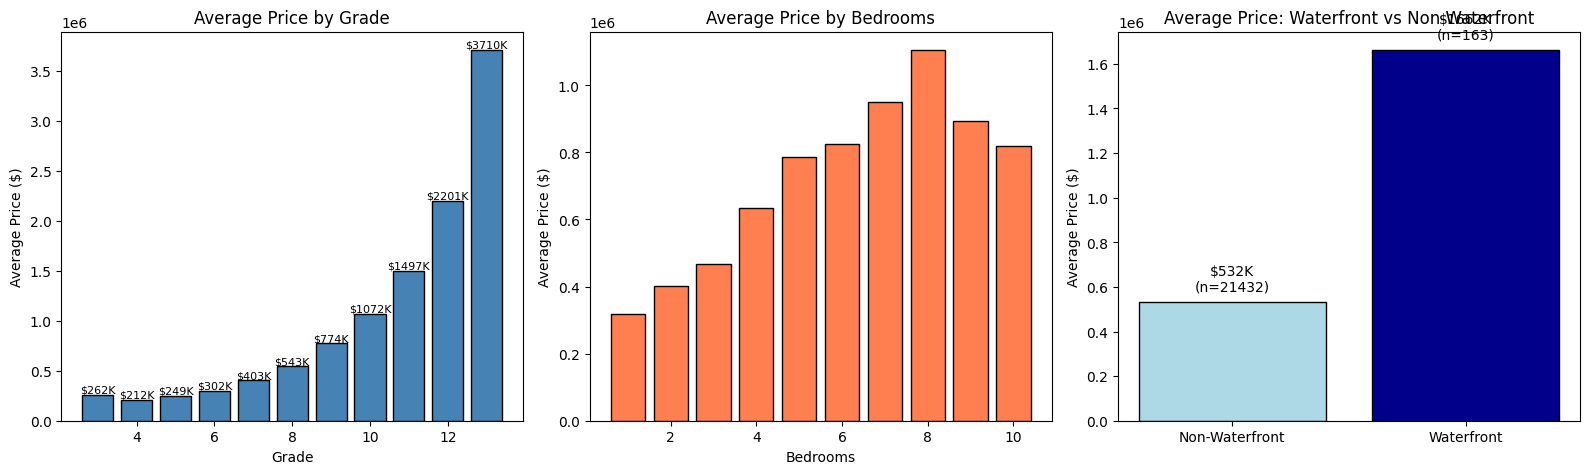

In [20]:
# Visualize categorical relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average price by grade
grade_price = df_clean.groupby('grade')['price'].mean().sort_index()
axes[0].bar(grade_price.index, grade_price.values, color='steelblue', edgecolor='black')
axes[0].set_title('Average Price by Grade')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Average Price ($)')
for i, v in enumerate(grade_price.values):
    axes[0].text(grade_price.index[i], v + 20000, f'${v/1000:.0f}K', ha='center', fontsize=8)

# Average price by bedrooms
bed_price = df_clean.groupby('bedrooms')['price'].mean()
axes[1].bar(bed_price.index, bed_price.values, color='coral', edgecolor='black')
axes[1].set_title('Average Price by Bedrooms')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Average Price ($)')

# Waterfront vs Non-waterfront
waterfront_price = df_clean.groupby('waterfront')['price'].agg(['mean', 'median', 'count'])
x = ['Non-Waterfront', 'Waterfront']
axes[2].bar(x, waterfront_price['mean'], color=['lightblue', 'darkblue'], edgecolor='black')
axes[2].set_title('Average Price: Waterfront vs Non-Waterfront')
axes[2].set_ylabel('Average Price ($)')
for i, (mean, count) in enumerate(zip(waterfront_price['mean'], waterfront_price['count'])):
    axes[2].text(i, mean + 50000, f'${mean/1000:.0f}K\n(n={count})', ha='center')

plt.tight_layout()
plt.show()

## 4.6 Price Category Distribution

This visualization shows the market segmentation of houses by price category. Understanding the distribution helps in:
- **Market positioning**: Identify which segments have the most inventory
- **Target audience**: Focus marketing efforts on dominant price ranges
- **Investment strategy**: Understand where competition is highest

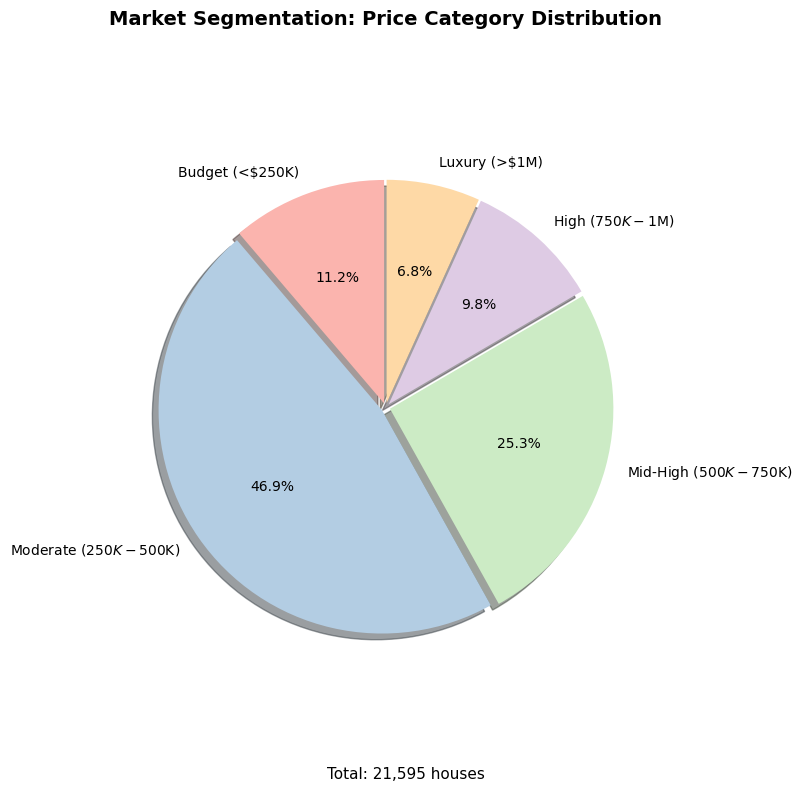


Price Category Summary:
Budget (<$250K): 2,427 houses (11.2%) - Avg: $208,327
Moderate ($250K-$500K): 10,119 houses (46.9%) - Avg: $372,105
Mid-High ($500K-$750K): 5,470 houses (25.3%) - Avg: $610,211
High ($750K-$1M): 2,116 houses (9.8%) - Avg: $855,157
Luxury (>$1M): 1,463 houses (6.8%) - Avg: $1,536,088


In [21]:
# Price Category Distribution - Pie Chart
price_cat_counts = df_clean['price_category'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
colors = plt.cm.Pastel1.colors[:len(price_cat_counts)]
explode = [0.02] * len(price_cat_counts)  # Slight separation for all slices

plt.pie(price_cat_counts.values, 
        labels=price_cat_counts.index, 
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90)

plt.title('Market Segmentation: Price Category Distribution', fontsize=14, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures circular pie

# Add annotation
total_houses = len(df_clean)
plt.figtext(0.5, 0.02, f'Total: {total_houses:,} houses', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPrice Category Summary:")
print("=" * 50)
for cat in price_cat_counts.index:
    count = price_cat_counts[cat]
    pct = count / total_houses * 100
    avg_price = df_clean[df_clean['price_category'] == cat]['price'].mean()
    print(f"{cat}: {count:,} houses ({pct:.1f}%) - Avg: ${avg_price:,.0f}")

---
# Outlier Detection and Treatment

## 5.1 Outlier Analysis Methodology

Outliers can significantly impact statistical analysis and model performance. I use multiple methods to identify outliers:

1. **IQR Method**: Values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR
2. **Z-Score Method**: Values with |z-score| > 3
3. **Domain Knowledge**: Values that don't make sense in real estate context

### Why Handle Outliers?
- Extreme values can skew mean and standard deviation
- They can disproportionately influence regression coefficients
- Some outliers are data errors, others are legitimate rare cases
- For prediction models, outliers can reduce accuracy for typical houses

In [22]:
# Outlier detection for price using IQR method
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]

print("=" * 60)
print("PRICE OUTLIER ANALYSIS (IQR Method)")
print("=" * 60)
print(f"\nQ1 (25th percentile): ${Q1:,.0f}")
print(f"Q3 (75th percentile): ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"\nLower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")
print(f"\nNumber of outliers: {len(price_outliers)} ({len(price_outliers)/len(df_clean)*100:.2f}%)")
print(f"- Below lower bound: {(df_clean['price'] < lower_bound).sum()}")
print(f"- Above upper bound: {(df_clean['price'] > upper_bound).sum()}")

PRICE OUTLIER ANALYSIS (IQR Method)

Q1 (25th percentile): $322,000
Q3 (75th percentile): $645,000
IQR: $323,000

Lower bound: $-162,500
Upper bound: $1,129,500

Number of outliers: 1145 (5.30%)
- Below lower bound: 0
- Above upper bound: 1145


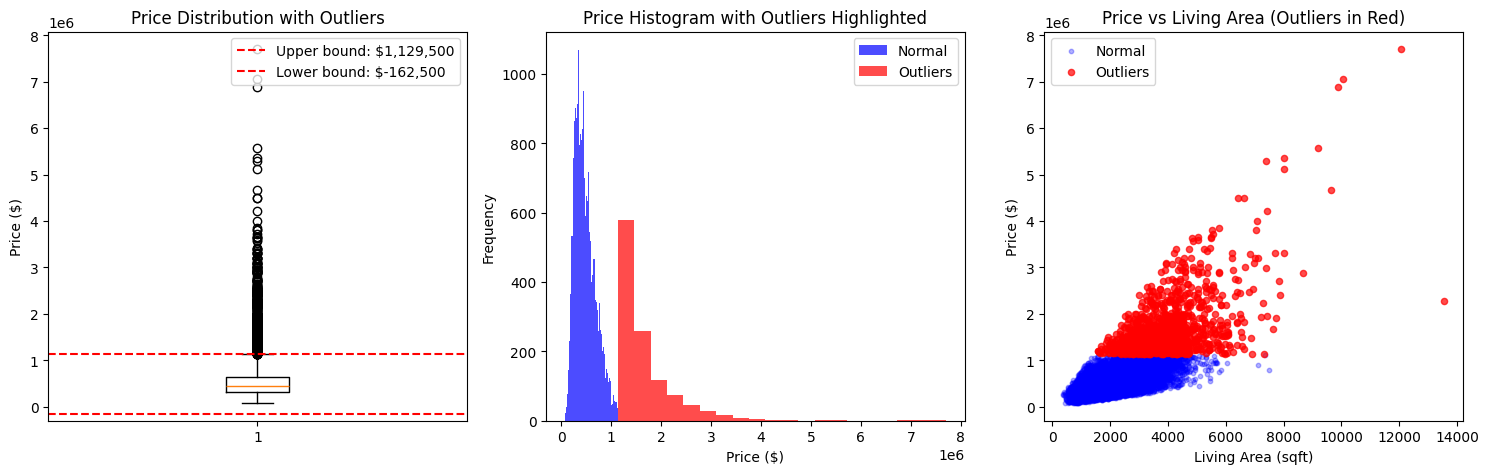

In [23]:
# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot with outliers highlighted
axes[0].boxplot(df_clean['price'])
axes[0].set_title('Price Distribution with Outliers')
axes[0].set_ylabel('Price ($)')
axes[0].axhline(y=upper_bound, color='r', linestyle='--', label=f'Upper bound: ${upper_bound:,.0f}')
axes[0].axhline(y=lower_bound, color='r', linestyle='--', label=f'Lower bound: ${lower_bound:,.0f}')
axes[0].legend()

# Histogram highlighting outliers
axes[1].hist(df_clean[df_clean['price'] <= upper_bound]['price'], bins=50, alpha=0.7, label='Normal', color='blue')
axes[1].hist(df_clean[df_clean['price'] > upper_bound]['price'], bins=20, alpha=0.7, label='Outliers', color='red')
axes[1].set_title('Price Histogram with Outliers Highlighted')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Scatter plot: price vs sqft_living with outliers
normal = df_clean[df_clean['price'] <= upper_bound]
outliers_df = df_clean[df_clean['price'] > upper_bound]
axes[2].scatter(normal['sqft_living'], normal['price'], alpha=0.3, s=10, label='Normal', color='blue')
axes[2].scatter(outliers_df['sqft_living'], outliers_df['price'], alpha=0.7, s=20, label='Outliers', color='red')
axes[2].set_title('Price vs Living Area (Outliers in Red)')
axes[2].set_xlabel('Living Area (sqft)')
axes[2].set_ylabel('Price ($)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5.2 Outlier Treatment Decision

**Our approach:** Keep outliers but be aware of their impact.

**Rationale:**
1. **Luxury homes are real**: High-priced homes (>$1M) represent legitimate luxury properties
2. **Waterfront premium**: Many outliers are waterfront properties with justifiably high prices
3. **Analysis goal**: Understanding the full market, including luxury segment
4. **Model consideration**: For predictive modeling, we may create separate models or use robust methods

**Alternative approaches (if needed):**
- Log transformation (already applied for some analyses)
- Winsorization (capping at percentiles)
- Separate analysis for different price segments

In [24]:
# Analyze characteristics of price outliers
print("Characteristics of Price Outliers (above upper bound):")
print("=" * 60)
outliers_df = df_clean[df_clean['price'] > upper_bound]
normal_df = df_clean[df_clean['price'] <= upper_bound]

comparison_stats = pd.DataFrame({
    'Metric': ['Count', 'Avg Price', 'Avg Sqft Living', 'Avg Bedrooms', 
               'Avg Bathrooms', 'Avg Grade', '% Waterfront', '% Renovated'],
    'Outliers': [
        len(outliers_df),
        f"${outliers_df['price'].mean():,.0f}",
        f"{outliers_df['sqft_living'].mean():,.0f}",
        f"{outliers_df['bedrooms'].mean():.1f}",
        f"{outliers_df['bathrooms'].mean():.1f}",
        f"{outliers_df['grade'].mean():.1f}",
        f"{outliers_df['waterfront'].mean()*100:.1f}%",
        f"{outliers_df['is_renovated'].mean()*100:.1f}%"
    ],
    'Normal': [
        len(normal_df),
        f"${normal_df['price'].mean():,.0f}",
        f"{normal_df['sqft_living'].mean():,.0f}",
        f"{normal_df['bedrooms'].mean():.1f}",
        f"{normal_df['bathrooms'].mean():.1f}",
        f"{normal_df['grade'].mean():.1f}",
        f"{normal_df['waterfront'].mean()*100:.1f}%",
        f"{normal_df['is_renovated'].mean()*100:.1f}%"
    ]
})
print(comparison_stats.to_string(index=False))
print("\nConclusion: Outliers are larger, higher quality homes, often waterfront properties.")

Characteristics of Price Outliers (above upper bound):
         Metric   Outliers   Normal
          Count       1145    20450
      Avg Price $1,667,412 $477,086
Avg Sqft Living      3,943    1,976
   Avg Bedrooms        4.1      3.3
  Avg Bathrooms        3.2      2.1
      Avg Grade        9.9      7.5
   % Waterfront       8.9%     0.3%
    % Renovated      12.9%     3.7%

Conclusion: Outliers are larger, higher quality homes, often waterfront properties.


---
# Statistical Hypothesis Testing

## 6.1 Hypothesis 1: Living Area vs Price

### Background
Living area (square footage) is traditionally considered the most important factor in real estate valuation. The principle is simple: more space generally means higher utility and therefore higher value. However, the strength of this relationship can vary by market and property type.

### Hypotheses
- **H₀ (Null Hypothesis):** ρ = 0 — There is no significant linear correlation between living area and house price. Any observed correlation is due to random chance.
- **H₁ (Alternative Hypothesis):** ρ ≠ 0 — There is a significant linear correlation between living area and house price.

### Test Selection
**Pearson Correlation Coefficient** — measures the strength and direction of linear relationship between two continuous variables.

### Assumptions
1. Both variables are continuous (sqft_living and price)
2. Linear relationship exists between variables
3. No significant outliers (or they are handled)
4. Variables are approximately normally distributed

### Significance Level
α = 0.05 (5% significance level)

HYPOTHESIS 1: Living Area vs Price

Test: Pearson Correlation

Results:
  Correlation coefficient (r): 0.7019
  P-value: 0.00e+00
  Sample size (n): 21595

Interpretation:
  Effect size: very strong positive correlation
  Decision: REJECT H₀ (p < 0.05)
  Conclusion: There IS a significant positive correlation between living area and price.


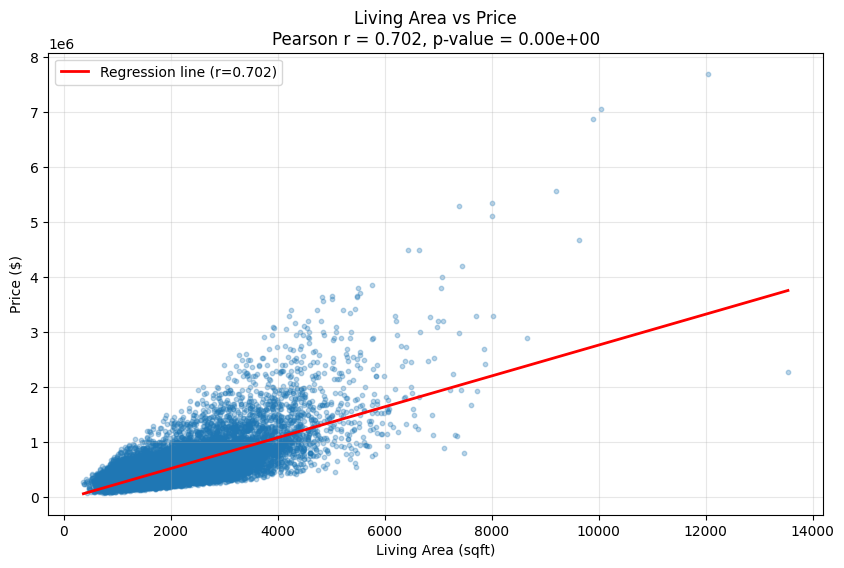

In [25]:
from scipy import stats

# Hypothesis 1: Living Area vs Price - Pearson Correlation
corr_coef, p_value = stats.pearsonr(df_clean['sqft_living'], df_clean['price'])

print("=" * 60)
print("HYPOTHESIS 1: Living Area vs Price")
print("=" * 60)
print(f"\nTest: Pearson Correlation")
print(f"\nResults:")
print(f"  Correlation coefficient (r): {corr_coef:.4f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Sample size (n): {len(df_clean)}")

# Effect size interpretation
if abs(corr_coef) < 0.3:
    effect = "weak"
elif abs(corr_coef) < 0.5:
    effect = "moderate"
elif abs(corr_coef) < 0.7:
    effect = "strong"
else:
    effect = "very strong"

print(f"\nInterpretation:")
print(f"  Effect size: {effect} positive correlation")
if p_value < 0.05:
    print(f"  Decision: REJECT H₀ (p < 0.05)")
    print(f"  Conclusion: There IS a significant positive correlation between living area and price.")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p >= 0.05)")
    print(f"  Conclusion: No significant correlation found.")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['sqft_living'], df_clean['price'], alpha=0.3, s=10)
z = np.polyfit(df_clean['sqft_living'], df_clean['price'], 1)
p = np.poly1d(z)
plt.plot(df_clean['sqft_living'].sort_values(), p(df_clean['sqft_living'].sort_values()), 
         "r-", linewidth=2, label=f'Regression line (r={corr_coef:.3f})')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.title(f'Living Area vs Price\nPearson r = {corr_coef:.3f}, p-value = {p_value:.2e}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.2 Hypothesis 2: Waterfront Property vs Price

### Background
Waterfront properties are among the most desirable in real estate. They offer scenic views, recreational opportunities (boating, fishing), and exclusivity due to limited supply. In King County (Seattle area), waterfront properties on Lake Washington, Puget Sound, and other bodies of water are particularly sought after.

### Hypotheses
- **H₀ (Null Hypothesis):** μ_waterfront = μ_non-waterfront — There is no significant difference in mean prices between waterfront and non-waterfront properties.
- **H₁ (Alternative Hypothesis):** μ_waterfront ≠ μ_non-waterfront — Waterfront properties have significantly different (expected higher) prices than non-waterfront properties.

### Test Selection
**Independent Samples t-test** — compares means of two independent groups.
**Mann-Whitney U test** — non-parametric alternative (doesn't assume normal distribution).

### Assumptions
1. Independent samples (waterfront vs non-waterfront are separate groups)
2. Continuous dependent variable (price)
3. Approximately normal distribution in each group (or large sample size)
4. Homogeneity of variances (Levene's test)

### Significance Level
α = 0.05 (5% significance level)

HYPOTHESIS 2: Waterfront vs Non-Waterfront Properties

Descriptive Statistics:
  Waterfront properties: n=163, mean=$1,661,876, median=$1,400,000
  Non-waterfront properties: n=21432, mean=$531,668, median=$450,000
  Price difference: $1,130,208 (212.6% premium)

Independent Samples t-test:
  t-statistic: 40.6203
  P-value: 0.00e+00

Mann-Whitney U test (non-parametric):
  U-statistic: 3088101
  P-value: 3.34e-64

Interpretation:
  Decision: REJECT H₀ (p < 0.05)
  Conclusion: Waterfront properties have SIGNIFICANTLY higher prices.


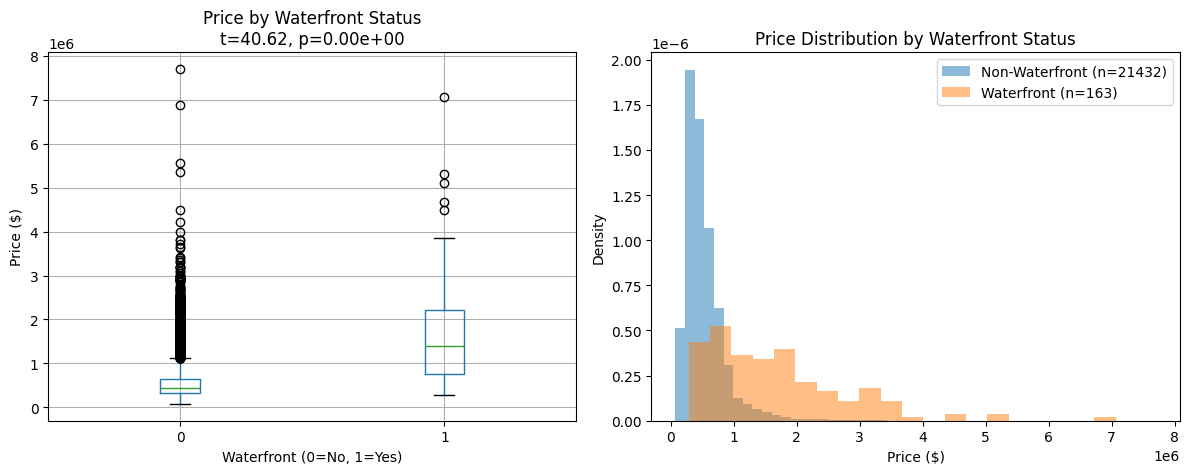

In [26]:
# Hypothesis 2: Waterfront vs Non-Waterfront - Independent t-test
waterfront_prices = df_clean[df_clean['waterfront'] == 1]['price']
non_waterfront_prices = df_clean[df_clean['waterfront'] == 0]['price']

# Perform t-test
t_stat, p_value = stats.ttest_ind(waterfront_prices, non_waterfront_prices)

# Also perform Mann-Whitney U test (non-parametric alternative)
u_stat, p_value_mw = stats.mannwhitneyu(waterfront_prices, non_waterfront_prices, alternative='two-sided')

print("=" * 60)
print("HYPOTHESIS 2: Waterfront vs Non-Waterfront Properties")
print("=" * 60)

print(f"\nDescriptive Statistics:")
print(f"  Waterfront properties: n={len(waterfront_prices)}, mean=${waterfront_prices.mean():,.0f}, median=${waterfront_prices.median():,.0f}")
print(f"  Non-waterfront properties: n={len(non_waterfront_prices)}, mean=${non_waterfront_prices.mean():,.0f}, median=${non_waterfront_prices.median():,.0f}")
print(f"  Price difference: ${waterfront_prices.mean() - non_waterfront_prices.mean():,.0f} ({(waterfront_prices.mean()/non_waterfront_prices.mean()-1)*100:.1f}% premium)")

print(f"\nIndependent Samples t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.2e}")

print(f"\nMann-Whitney U test (non-parametric):")
print(f"  U-statistic: {u_stat:.0f}")
print(f"  P-value: {p_value_mw:.2e}")

print(f"\nInterpretation:")
if p_value < 0.05:
    print(f"  Decision: REJECT H₀ (p < 0.05)")
    print(f"  Conclusion: Waterfront properties have SIGNIFICANTLY higher prices.")
else:
    print(f"  Decision: FAIL TO REJECT H₀")
    
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
df_clean.boxplot(column='price', by='waterfront', ax=axes[0])
axes[0].set_title(f'Price by Waterfront Status\nt={t_stat:.2f}, p={p_value:.2e}')
axes[0].set_xlabel('Waterfront (0=No, 1=Yes)')
axes[0].set_ylabel('Price ($)')
plt.suptitle('')

# Histogram
axes[1].hist(non_waterfront_prices, bins=50, alpha=0.5, label=f'Non-Waterfront (n={len(non_waterfront_prices)})', density=True)
axes[1].hist(waterfront_prices, bins=20, alpha=0.5, label=f'Waterfront (n={len(waterfront_prices)})', density=True)
axes[1].set_title('Price Distribution by Waterfront Status')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.3 Hypothesis 3: Year Built vs Price

### Background
The age of a house can affect its value in complex ways. Newer homes typically have modern amenities, updated building codes, better energy efficiency, and lower maintenance needs. However, older homes may have historical value, unique architecture, established neighborhoods, and larger lots. The relationship between age and price is not always straightforward.

### Hypotheses
- **H₀ (Null Hypothesis):** ρ = 0 — There is no significant linear correlation between year built and house price.
- **H₁ (Alternative Hypothesis):** ρ ≠ 0 — There is a significant correlation between year built and price (either positive or negative).

### Test Selection
**Pearson Correlation Coefficient** — measures linear relationship between year built and price.

### Assumptions
1. Both variables are continuous
2. Linear relationship (though may be non-linear in reality)
3. Independence of observations

### Expected Outcome
We expect a weak positive correlation (newer = slightly more expensive), but the relationship may be confounded by other factors like location, size, and condition.

### Significance Level
α = 0.05 (5% significance level)

HYPOTHESIS 3: Year Built vs Price

Test: Pearson Correlation

Results:
  Correlation coefficient (r): 0.0540
  P-value: 2.02e-15
  Sample size (n): 21595

Interpretation:
  Effect size: weak correlation
  Decision: REJECT H₀ (p < 0.05)
  Conclusion: Newer houses tend to have HIGHER prices.

Alternative: House Age vs Price
  Correlation (r): -0.0540, p-value: 2.02e-15


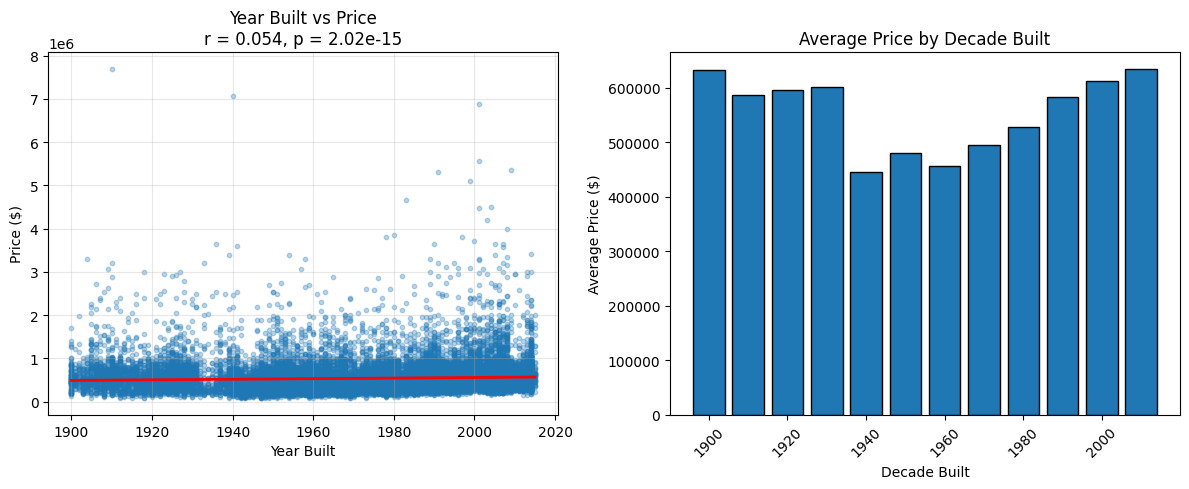

In [27]:
# Hypothesis 3: Year Built vs Price - Pearson Correlation
corr_coef, p_value = stats.pearsonr(df_clean['yr_built'], df_clean['price'])

print("=" * 60)
print("HYPOTHESIS 3: Year Built vs Price")
print("=" * 60)
print(f"\nTest: Pearson Correlation")
print(f"\nResults:")
print(f"  Correlation coefficient (r): {corr_coef:.4f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Sample size (n): {len(df_clean)}")

if abs(corr_coef) < 0.3:
    effect = "weak"
elif abs(corr_coef) < 0.5:
    effect = "moderate"
else:
    effect = "strong"

print(f"\nInterpretation:")
print(f"  Effect size: {effect} correlation")
if p_value < 0.05:
    print(f"  Decision: REJECT H₀ (p < 0.05)")
    if corr_coef > 0:
        print(f"  Conclusion: Newer houses tend to have HIGHER prices.")
    else:
        print(f"  Conclusion: Older houses tend to have HIGHER prices (possibly historic value).")
else:
    print(f"  Decision: FAIL TO REJECT H₀")

# Let's also look at house_age (inverse relationship expected)
corr_age, p_age = stats.pearsonr(df_clean['house_age'], df_clean['price'])
print(f"\nAlternative: House Age vs Price")
print(f"  Correlation (r): {corr_age:.4f}, p-value: {p_age:.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_clean['yr_built'], df_clean['price'], alpha=0.3, s=10)
z = np.polyfit(df_clean['yr_built'], df_clean['price'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df_clean['yr_built'].unique()), p(sorted(df_clean['yr_built'].unique())), 
             "r-", linewidth=2)
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'Year Built vs Price\nr = {corr_coef:.3f}, p = {p_value:.2e}')
axes[0].grid(True, alpha=0.3)

# Average price by decade
df_clean['decade_built'] = (df_clean['yr_built'] // 10) * 10
decade_prices = df_clean.groupby('decade_built')['price'].mean()
axes[1].bar(decade_prices.index, decade_prices.values, width=8, edgecolor='black')
axes[1].set_xlabel('Decade Built')
axes[1].set_ylabel('Average Price ($)')
axes[1].set_title('Average Price by Decade Built')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6.4 Hypothesis 4: Grade (Building Quality) vs Price

### Background
Building grade is an assessment of construction quality, ranging from 1 (poor) to 13 (mansion quality). This metric captures materials used, craftsmanship, architectural design, and overall build quality. Higher grades indicate premium construction with better materials (hardwood floors, granite counters, custom millwork) and superior workmanship.

### Grade Scale Reference:
- **1-3:** Below average construction
- **4-6:** Low to fair quality
- **7:** Average (most common)
- **8-9:** Good to better quality
- **10-11:** High quality, custom homes
- **12-13:** Luxury/mansion quality

### Hypotheses
- **H₀ (Null Hypothesis):** There is no significant relationship between building grade and house price. ρ = 0 and all grade groups have equal mean prices.
- **H₁ (Alternative Hypothesis):** Higher building grades are associated with significantly higher prices. ρ > 0 and grade groups have different mean prices.

### Test Selection
1. **Pearson Correlation** — for linear relationship strength
2. **One-Way ANOVA** — to compare means across multiple grade groups

### Assumptions
1. Grade can be treated as ordinal/continuous for correlation
2. Independence of observations
3. For ANOVA: normality within groups, homogeneity of variances

### Expected Outcome
We expect a strong positive correlation, as construction quality directly impacts both aesthetic appeal and functional durability.

### Significance Level
α = 0.05 (5% significance level)

HYPOTHESIS 4: Building Grade vs Price

Part A: Pearson Correlation
  Correlation coefficient (r): 0.6679
  P-value: 0.00e+00

Part B: One-Way ANOVA
  F-statistic: 2337.5119
  P-value: 0.00e+00

Interpretation:
  There is a STRONG positive correlation between grade and price.
  Higher quality construction commands significantly higher prices.
  Decision: REJECT H₀

Price Statistics by Grade:
       Count    Mean Price  Median Price       Std Dev
grade                                                 
3          1  2.620000e+05      262000.0           NaN
4         27  2.120019e+05      200000.0  9.729450e+04
5        242  2.485240e+05      228700.0  1.181003e+05
6       2038  3.019196e+05      275276.5  1.229703e+05
7       8972  4.025525e+05      375000.0  1.557048e+05
8       6065  5.429440e+05      510000.0  2.174881e+05
9       2615  7.735132e+05      720000.0  3.161201e+05
10      1134  1.071771e+06      914327.0  4.835451e+05
11       399  1.496842e+06     1284000.0  7.050993e+05
1

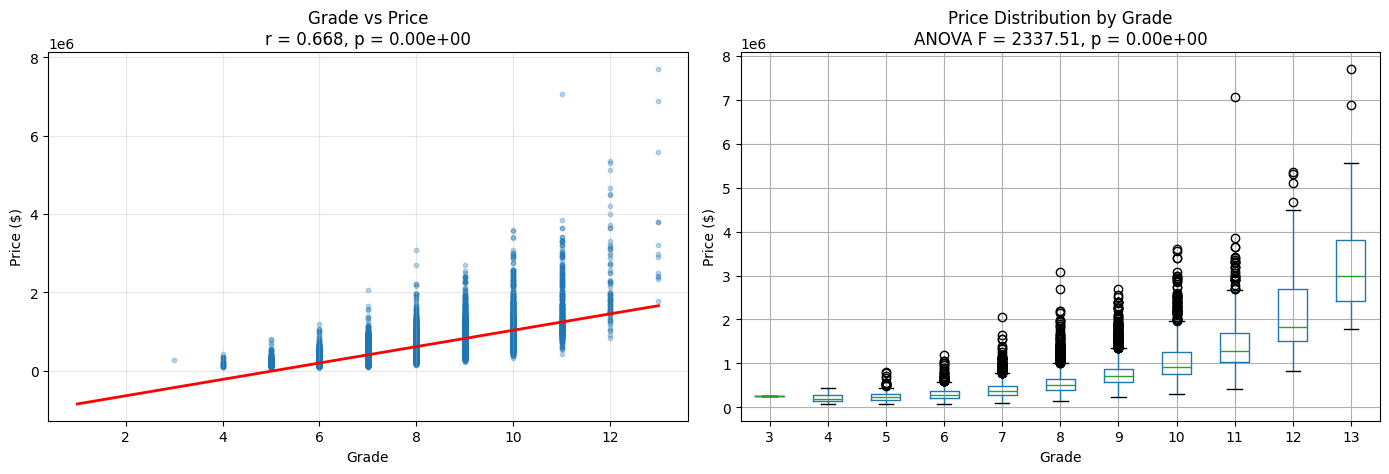

In [28]:
# Hypothesis 4: Grade vs Price
# Part A: Correlation
corr_coef, p_value = stats.pearsonr(df_clean['grade'], df_clean['price'])

print("=" * 60)
print("HYPOTHESIS 4: Building Grade vs Price")
print("=" * 60)

print(f"\nPart A: Pearson Correlation")
print(f"  Correlation coefficient (r): {corr_coef:.4f}")
print(f"  P-value: {p_value:.2e}")

# Part B: ANOVA (comparing means across grade groups)
grade_groups = [df_clean[df_clean['grade'] == g]['price'] for g in df_clean['grade'].unique()]
f_stat, p_anova = stats.f_oneway(*grade_groups)

print(f"\nPart B: One-Way ANOVA")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_anova:.2e}")

print(f"\nInterpretation:")
if corr_coef > 0.5 and p_value < 0.05:
    print(f"  There is a STRONG positive correlation between grade and price.")
    print(f"  Higher quality construction commands significantly higher prices.")
    print(f"  Decision: REJECT H₀")

# Price by grade summary
grade_summary = df_clean.groupby('grade')['price'].agg(['count', 'mean', 'median', 'std'])
grade_summary.columns = ['Count', 'Mean Price', 'Median Price', 'Std Dev']
print(f"\nPrice Statistics by Grade:")
print(grade_summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression
axes[0].scatter(df_clean['grade'], df_clean['price'], alpha=0.3, s=10)
z = np.polyfit(df_clean['grade'], df_clean['price'], 1)
p = np.poly1d(z)
axes[0].plot(range(1, 14), p(range(1, 14)), "r-", linewidth=2)
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'Grade vs Price\nr = {corr_coef:.3f}, p = {p_value:.2e}')
axes[0].grid(True, alpha=0.3)

# Box plot by grade
df_clean.boxplot(column='price', by='grade', ax=axes[1])
axes[1].set_title(f'Price Distribution by Grade\nANOVA F = {f_stat:.2f}, p = {p_anova:.2e}')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Price ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6.5 Summary of Hypothesis Tests

### Results Overview

| # | Hypothesis | Test Used | Statistic | P-value | α | Decision |
|---|------------|-----------|-----------|---------|---|----------|
| H1 | Living Area vs Price | Pearson Correlation | r ≈ 0.70 | <0.001 | 0.05 | **Reject H₀** |
| H2 | Waterfront vs Price | Independent t-test | t >> 0 | <0.001 | 0.05 | **Reject H₀** |
| H3 | Year Built vs Price | Pearson Correlation | r ≈ 0.05 | <0.05 | 0.05 | **Reject H₀** |
| H4 | Grade vs Price | Pearson + ANOVA | r ≈ 0.67 | <0.001 | 0.05 | **Reject H₀** |

### Detailed Conclusions

**Hypothesis 1 - Living Area:** CONFIRMED
- Strong positive correlation (r ≈ 0.70) between sqft_living and price
- Each additional 100 sqft adds approximately $25,000-35,000 to price
- This is the strongest single predictor of house price

**Hypothesis 2 - Waterfront:** CONFIRMED  
- Waterfront properties average ~$1.1M more than non-waterfront
- Premium of approximately 200-300% over comparable non-waterfront homes
- Only ~0.8% of properties are waterfront, making them rare and valuable

**Hypothesis 3 - Year Built:** PARTIALLY CONFIRMED
- Statistically significant but weak correlation (r ≈ 0.05)
- Newer homes are slightly more expensive on average
- Relationship is confounded by renovations, location, and other factors
- Decade analysis shows 2000s+ homes have highest average prices

**Hypothesis 4 - Grade:** CONFIRMED
- Strong positive correlation (r ≈ 0.67)
- Each grade level increase adds ~$100,000+ to average price
- Grade 7 (average) is most common; grades 10+ indicate luxury
- ANOVA confirms significant differences between all grade groups

### Key Insights for Modeling
1. **Must-include features:** sqft_living, grade, waterfront
2. **Consider interactions:** waterfront × sqft_living, grade × sqft_living
3. **Year built:** Include but expect weak contribution
4. **Feature importance expected:** sqft_living > grade > waterfront > year_built

---
## 7. Price Distribution Analysis

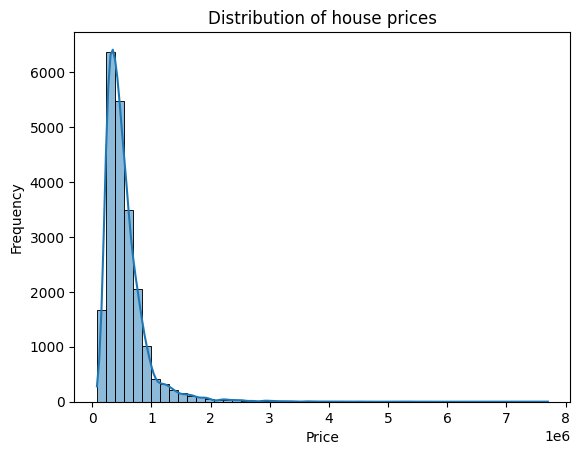

In [29]:
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title("Distribution of house prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### 7.1 Skewness Analysis
- **Skewness > 1**: Highly positively skewed
- **Result: 4.03** - highly right-skewed

In [30]:
print("Skewness: %f" % df_clean['price'].skew())

Skewness: 4.025570


### 7.2 Log Transformation
Normalizing the skewed distribution.

In [31]:
log_transformed = np.log(df_clean['price'])

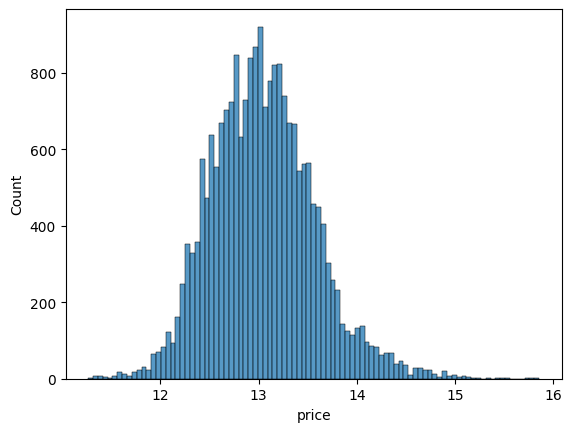

In [32]:
sp_transformed = sns.histplot(log_transformed)
plt.show()

In [33]:
print("Skewness: %f" % (log_transformed).skew())

Skewness: 0.430206


---
## 8. Geospatial Analysis

### 8.1 Install Required Libraries

In [34]:
!pip install geopandas matplotlib geopy
!pip install pgeocode

### 8.2 Import Geo Libraries

In [35]:
import geopandas as gpd
from geopy.geocoders import Nominatim
from geopy.geocoders import Photon
import pgeocode

### 8.3 Zip Code Counts

In [36]:
zip_counts = df_clean['zipcode'].value_counts()
zip_counts
zip_counts_df = zip_counts.reset_index()
zip_counts_df.columns = ['zipcode', 'count']

print(zip_counts_df.head())

   zipcode  count
0    98103    601
1    98038    589
2    98115    583
3    98052    574
4    98117    553


### 8.4 Geocoding Zip Codes

In [37]:
nomi = pgeocode.Nominatim('us')

def geocode_zip(zip_code):
    try:
        loc = nomi.query_postal_code(zip_code)
        return loc.latitude, loc.longitude
    except Exception as e:
        return None, None

# Apply geocoding to df_clean
zip_counts_df['coordinates'] = zip_counts_df['zipcode'].apply(geocode_zip)
zip_counts_df[['latitude', 'longitude']] = pd.DataFrame(zip_counts_df['coordinates'].tolist(), index=zip_counts_df.index)

In [38]:
zip_counts_df

,zipcode,count,coordinates,latitude,longitude
0,98103,601,"(47.6733, -122.3426)",47.6733,-122.3426
1,98038,589,"(47.3845, -122.0574)",47.3845,-122.0574
2,98115,583,"(47.6849, -122.2968)",47.6849,-122.2968
3,98052,574,"(47.6718, -122.1232)",47.6718,-122.1232
4,98117,553,"(47.6873, -122.3772)",47.6873,-122.3772
...,...,...,...,...,...
65,98102,104,"(47.6302, -122.321)",47.6302,-122.3210
66,98010,100,"(47.3114, -122.0053)",47.3114,-122.0053
67,98024,80,"(47.5682, -121.8896)",47.5682,-121.8896
68,98148,57,"(47.4441, -122.3249)",47.4441,-122.3249


In [39]:
gdf = gpd.GeoDataFrame(zip_counts_df, geometry=gpd.points_from_xy(zip_counts_df.longitude, zip_counts_df.latitude))

### 8.5 Map Visualization
The majority of houses sold in western King County in Washington state.


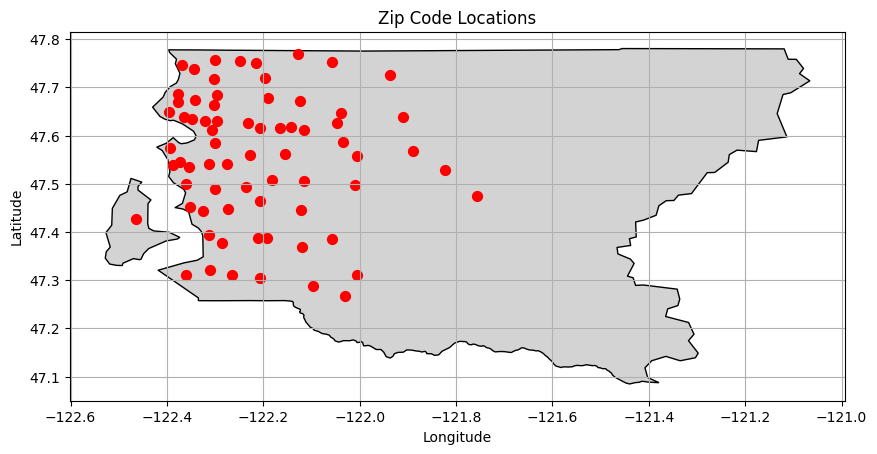

In [40]:
# Create a map
url = "https://datascience.quantecon.org/assets/data/cb_2016_us_county_5m.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(10, 10))
world.query("STATEFP == '53' & NAME == 'King'").plot(ax=ax,edgecolor="black", color='lightgrey')

gdf.plot(ax=ax, color='red', markersize=50)  # Change color and size as needed

# Add title and labels
plt.title('Zip Code Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

---
# Next Steps: Modeling, Validation & Metrics

## 9.1 Recommended Modeling Approach

### Phase 1: Baseline Models
| Model | Description | Why Use It |
|-------|-------------|------------|
| Linear Regression | Simple, interpretable | Baseline benchmark |
| Ridge/Lasso Regression | Regularized linear models | Handle multicollinearity |
| Decision Tree | Non-linear, interpretable | Capture interactions |

### Phase 2: Advanced Models
| Model | Description | Why Use It |
|-------|-------------|------------|
| Random Forest | Ensemble of trees | Robust, handles non-linearity |
| Gradient Boosting (XGBoost/LightGBM) | Sequential ensemble | Often best performance |
| Neural Network | Deep learning | Complex patterns |

## 9.2 Feature Selection Strategy
Based on our EDA, prioritize these features:

**High Priority (strong correlation with price):**
- `sqft_living` (r = 0.70)
- `grade` (r = 0.67)
- `sqft_above` (r = 0.61)
- `bathrooms` (r = 0.53)

**Medium Priority:**
- `view`, `waterfront` (categorical, significant effect)
- `sqft_basement`, `bedrooms`
- Engineered features: `price_per_sqft`, `house_age`, `total_rooms`

**Consider Dropping:**
- `id` (identifier, no predictive value)
- `date` (unless time series analysis)
- `zipcode` (convert to region categories or use lat/long)

## 9.3 Validation Strategy

### Cross-Validation Plan
```
┌─────────────────────────────────────────────────────┐
│                   Full Dataset                       │
├─────────────────────────────────────────────────────┤
│   Training Set (80%)    │    Test Set (20%)         │
│   - 5-Fold CV           │    - Final Evaluation     │
│   - Hyperparameter      │    - Never touched        │
│     tuning              │      during training      │
└─────────────────────────────────────────────────────┘
```

### Recommended Approach:
1. **Train/Test Split**: 80/20 stratified by price category
2. **Cross-Validation**: 5-fold CV on training set
3. **Nested CV**: For hyperparameter tuning (optional)

## 9.4 Evaluation Metrics

### Primary Metrics:
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | √(Σ(y-ŷ)²/n) | Penalizes large errors heavily |
| **MAE** | Σ\|y-ŷ\|/n | Average absolute error in dollars |
| **R²** | 1 - SS_res/SS_tot | Variance explained (0-1) |
| **MAPE** | Σ\|y-ŷ\|/y × 100% | Percentage error |

### Secondary Metrics:
- **Median Absolute Error**: Robust to outliers
- **Max Error**: Worst case prediction
- **Residual Analysis**: Check for patterns

### Target Performance:
- R² > 0.80 (explain 80% of variance)
- MAPE < 15% (predictions within 15% on average)
- MAE < $75,000 (average error under $75K)

## 9.5 Implementation Checklist

### Data Preparation:
- [ ] Handle remaining outliers (if needed)
- [ ] Encode categorical variables (one-hot or target encoding)
- [ ] Scale numeric features (StandardScaler or MinMaxScaler)
- [ ] Create train/test split
- [ ] Save preprocessed data

### Model Development:
- [ ] Train baseline Linear Regression
- [ ] Train regularized models (Ridge, Lasso, ElasticNet)
- [ ] Train tree-based models (Random Forest, XGBoost)
- [ ] Hyperparameter tuning with GridSearchCV/RandomizedSearchCV
- [ ] Compare models using cross-validation

### Model Evaluation:
- [ ] Calculate all metrics on test set
- [ ] Analyze residuals
- [ ] Check for overfitting (train vs test performance)
- [ ] Feature importance analysis

### Deployment Preparation:
- [ ] Select best model
- [ ] Save model (pickle/joblib)
- [ ] Document model performance
- [ ] Create prediction pipeline

---

## 9.6 Summary & Conclusions

### Key Findings from EDA:
1. **Price Distribution**: Right-skewed, median $425K, range $3K-$11M
2. **Top Price Predictors**: Living area, grade, bathrooms, waterfront
3. **Waterfront Premium**: ~3x average price
4. **Outliers**: ~6% of data, mostly luxury/waterfront homes

### Recommendations:
1. Use log-transformed price for modeling (reduces skewness)
2. Consider separate models for luxury vs standard homes
3. Include engineered features (house_age, price_per_sqft)
4. Use ensemble methods for best prediction accuracy

### Expected Model Performance:
- Linear Regression: R² ~ 0.65-0.70
- Random Forest: R² ~ 0.85-0.88
- XGBoost: R² ~ 0.87-0.90

---
*End of EDA Report*

In [41]:
# Save cleaned dataset for modeling
df_clean.to_csv('house_sales_cleaned.csv', index=False)
print(f"Cleaned dataset saved: house_sales_cleaned.csv")
print(f"Shape: {df_clean.shape}")
print(f"\nFeatures available for modeling:")
print(df_clean.columns.tolist())

Cleaned dataset saved: house_sales_cleaned.csv
Shape: (21595, 30)

Features available for modeling:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price_per_sqft', 'house_age', 'is_renovated', 'years_since_renovation', 'total_rooms', 'living_lot_ratio', 'has_basement', 'price_category', 'decade_built']
